# Zero-shot screening — v2, corrected

Supersedes `zeroshot_calibration.ipynb`. Same idea, six fixes, one of which changes the
conclusion table.

## What was wrong in v1

**A bug in `wss()`.** It returned `(1 − fraction_screened) − (1 − TARGET)` instead of
`(1 − fraction_screened) − (1 − recall_actually_achieved)`. WSS@95 is only meaningful when
recall really reaches 95%; subtracting the *target* credits a method that threw away most of
the eligible records as though it had kept them. That is how the TF-IDF baseline came out on
top with WSS 83.5% at recall 0.278 — it discarded 88.5% of the pool while losing 72% of the
eligible articles.

Corrected, using the numbers v1 already printed:

| approach | WSS@95 (v1, wrong) | WSS@95 (corrected) | recall out-of-fold | valid? |
|---|---|---|---|---|
| Embedding max-sim | 29.7 | **30.9** | 0.962 | yes |
| S3 softmin λ=1.0 | 24.1 | **24.2** | 0.951 | yes |
| S2 conjunctive | 23.5 | 23.6 | 0.951 | yes |
| S0 original rule | 16.7 | 16.7 | 0.950 | yes |
| S1 normalised max | 13.0 | 14.2 | 0.962 | yes |
| Hybrid | 45.9 | 37.7 | 0.868 | **no** |
| S4 logistic | 40.3 | 32.9 | 0.876 | **no** |
| TF-IDF + LogReg | 83.5 | 16.3 | 0.278 | **no** |
| Fine-tuned DeBERTa | 12.4 | 12.4 | 0.980 | yes |

"valid" means the method actually held 95% recall on held-out data. A method that did not
cannot be reported at WSS@95 at all — it would have to lower its threshold, and the saving
would fall with it.

## The six fixes in this version

| # | Fix | Why |
|---|---|---|
| 1 | `wss()` uses achieved recall; every table carries a `holds_95` flag | the bug above |
| 2 | Operating threshold fitted with a **safety margin chosen by inner CV** | fitting at exactly 95% in-fold puts the cut on a high-variance order statistic, so out-of-fold recall lands below target (0.876, 0.868, 0.278 in v1) |
| 3 | λ for S3 and the veto parameters for S5 fitted **inside the training fold** | v1 picked λ by looking at AUC on the whole labelled pool, which is selection on the evaluation data |
| 4 | Four harmful hypotheses rewritten, `comfort` split into three | leave-one-out showed removing `rule3_construct` (+0.0143), `env/safety` (+0.0115), `env/accessibility_layout` (+0.0065) and `sensor/field_device` (+0.0059) *improved* the score, while `env/comfort` alone was worth +0.0414 |
| 5 | **S5**: exclusion as a hinge veto rather than a subtraction | at threshold −0.721 a record passed even when the exclusion signal beat both required facets by 0.7 — hence 64 false positives against 3 false negatives |
| 6 | Ablation re-run against **out-of-fold WSS**, not AUC | AUC is not the operating metric; a sentence can help ranking and hurt at the cut point |

Plus a new §12 that surfaces the virtual-reality records, because those are an unresolved
question about the criterion rather than a defect of the classifier — see the note there.

Only the edited hypotheses get re-scored; the rest load from the v1 cache.

## 1. Configuration

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import os, json, time, hashlib, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR  = "../model/dataset"
OUT_DIR   = "../model/output"
CACHE_DIR = "../model/cache"          # same cache as v1 - unchanged sentences are reused
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(CACHE_DIR, exist_ok=True)

POS = "Sensing of walkability dimension"
NEG = "Not related"

NLI_MODEL  = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
EMB_MODEL  = "sentence-transformers/all-mpnet-base-v2"
MAX_LEN    = 512
BATCH_SIZE = 16

TARGET_RECALL = 0.95
# FIX 2: the in-fold recall the threshold is fitted at may exceed the target.
# Which margin to use is chosen by inner cross-validation, never by hand.
MARGIN_GRID = (0.95, 0.97, 0.98, 0.99, 1.00)
N_SPLITS, N_REPEATS = 5, 10
INNER_SPLITS = 4

CORPUS_PREVALENCE = None      # set once you have a random corpus sample

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")

Device: cuda | CUDA: True


## 2. The labelled pool

Unchanged from v1: `real.json` (67) and `diagnostic_test.json` (125) pooled into 192 real
abstracts, 72 of them eligible (37.5%). Nothing is trained on them, so pooling costs nothing
and buys statistical power.

In [2]:
# ============================================================
# 1. Load and pool the real labelled abstracts
# ============================================================
def load_json(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)

frames = []
for name in ["real", "diagnostic_test"]:
    p = f"{DATA_DIR}/{name}.json"
    if not os.path.exists(p):
        print(f"  [missing] {p}"); continue
    d = pd.DataFrame(load_json(p))[["text", "label"]]
    d["origin"] = name
    frames.append(d)
    print(f"  {name:16s} -> {len(d):4d}")

pool = pd.concat(frames, ignore_index=True)
pool["text"] = pool["text"].astype(str).str.strip()
pool["key"] = (pool["text"].str.lower()
                    .str.replace(r"[^a-z0-9 ]", " ", regex=True)
                    .str.replace(r"\s+", " ", regex=True).str.strip())
conflict = pool.groupby("key")["label"].nunique().loc[lambda s: s > 1]
if len(conflict):
    print(f"\n[!] {len(conflict)} texts with conflicting labels - dropped")
    pool = pool[~pool["key"].isin(conflict.index)]
pool = pool.drop_duplicates("key").reset_index(drop=True)

pool["y"] = (pool["label"] == POS).astype(int)
y = pool["y"].values
texts = pool["text"].tolist()
print(f"\nPooled: {len(pool)} | positives {y.sum()} ({y.mean()*100:.1f}%) "
      f"| negatives {(1-y).sum()}")

  real             ->   67
  diagnostic_test  ->  125

Pooled: 192 | positives 72 (37.5%) | negatives 120


## 3. Hypothesis bank v2 — what changed and why

Each hypothesis now carries a `tier` (the Alfonzo dimension, or the adjudication rule for
exclusions) separately from its `tag`, so splitting a sentence into three does not fragment
the tier-level diagnostic in §9.

**Rewritten, because leave-one-out said they were doing harm:**

- `sensor/field_device` — *"collects data with a physical sensor, camera or measurement
  device"* is entailed by almost any empirical urban paper, so it fired constantly and told
  the aggregator nothing. Narrowed to instruments actually deployed on a street.
- `env/safety` — the old wording included *"exposure to vehicle traffic"*, which is entailed
  by crash-risk and driver-behaviour studies. Those are the exact false positives v1
  produced (`Searching for Street Parking: Effects on Driver Vehicle Control...`). Narrowed
  to physical safety infrastructure, anchored on people walking.
- `env/accessibility_layout` — *"layout or connectivity of the pedestrian network"* is what
  a GIS walkability index measures without any sensor, so it pulled in exactly the records
  `excl/no_sensor` was meant to remove. Re-aimed at physically observed continuity.
- `excl/rule3_construct` — had AUC 0.550, i.e. it was *positively* associated with
  eligibility, because genuine walkability papers routinely mention property value and crime
  as motivation. Re-aimed at the study's stated objective rather than its topic.

**Split, because it was the strongest sentence in the bank (+0.0414 on its own):**
`env/comfort` becomes three — thermal, acoustic, air quality. One sentence asserting three
different measurements is a disjunction the NLI model has to average over.

**Also fixed:** `excl/clinical` was catching assistive technology for pedestrians (it
rejected a tactile-paving detection paper because of the phrase *visually impaired people*),
so it is now anchored on clinics and laboratory walkways.

**New:** `flag/virtual` — see §12. Virtual-environment studies are not classified here; they
are surfaced for you to adjudicate, because the criterion does not yet cover them.

In [3]:
# ============================================================
# 2. Hypothesis bank v2 - facet | tier | tag | sentence
# ============================================================
HYPOTHESES = [
    # ---------- SENSOR: is an instrument acquiring data? ----------
    ("sensor", "sensor", "field_device",   "Data were collected by an instrument installed on a street, such as a fixed camera, a sensor node or a survey vehicle."),
    ("sensor", "sensor", "street_imagery", "The study derives measurements from street-level photographs such as Google Street View panoramas."),
    ("sensor", "sensor", "lidar",          "The study uses LiDAR, point clouds or depth sensing to measure physical geometry."),
    ("sensor", "sensor", "mobile",         "The study uses smartphone sensors, wearable devices or accelerometers to record conditions along a route."),
    ("sensor", "sensor", "environmental",  "The study uses instruments to record temperature, noise or air pollution at a specific location."),
    ("sensor", "sensor", "cv",             "The study applies computer vision or deep learning to images in order to extract measurements."),

    # ---------- ENVIRONMENT: is the measured object a walkability attribute? ----------
    ("env", "feasibility",    "surface",      "The measured object is the sidewalk surface, its width, its continuity or its state of repair."),
    ("env", "accessibility",  "barriers",     "The measured object is slope, steps, kerb ramps or physical barriers along a pedestrian route."),
    ("env", "accessibility",  "continuity",   "The measured object is whether the walking route is physically obstructed or interrupted on the ground."),
    ("env", "safety",         "crossings",    "The measured object is the presence or condition of crosswalks, kerbs, traffic signals or street lighting where people walk."),
    ("env", "comfort",        "thermal",      "The measured object is air temperature, radiant heat or shade experienced by a person on the street."),
    ("env", "comfort",        "acoustic",     "The measured object is the level of noise on the street."),
    ("env", "comfort",        "air_quality",  "The measured object is the concentration of air pollutants at the height a pedestrian breathes."),
    ("env", "pleasurability", "streetscape",  "The measured object is street greenery, building facades, enclosure or the visual quality of the streetscape."),
    ("env", "general",        "general",      "The measured object is a physical characteristic of the street environment where people walk."),
    ("env", "general",        "walkability",  "The study assesses the walkability of an urban area."),

    # ---------- EXCLUSION: tagged with the adjudication rule ----------
    ("excl", "rule1_source",    "aerial",      "The measurements are taken from satellite or aerial imagery captured from above, not from ground level."),
    ("excl", "rule2_stimulus",  "stimulus",    "Images are shown to human participants as stimuli in a survey or a preference experiment."),
    ("excl", "rule3_construct", "construct",   "The stated objective of the study is to predict crime, housing prices or real-estate value."),
    ("excl", "outcome",         "health",      "The outcome of interest is the physical activity, health or step count of individuals."),
    ("excl", "outcome",         "behaviour",   "The study measures where people walk or how much they walk, rather than the street they walk on."),
    ("excl", "off_domain",      "vehicles",    "The study is about vehicles, cyclists, e-scooters, robots or autonomous driving."),
    ("excl", "off_domain",      "clinical",    "The study analyses the gait of patients in a clinic or on a laboratory walkway."),
    ("excl", "no_sensor",       "gis_index",   "The measure is computed from geographic databases or census data without any sensing."),
    ("excl", "simulation",      "simulation",  "The results come from a computer simulation or an agent-based model rather than from measurement."),

    # ---------- FLAG: surfaced for adjudication, NOT used in the score ----------
    ("flag", "virtual", "virtual", "The study takes place in a virtual reality environment or a computer-generated street."),
]

H = pd.DataFrame(HYPOTHESES, columns=["facet", "tier", "tag", "text"])
assert H["text"].is_unique, "Duplicate hypothesis sentences."
assert H["tag"].is_unique, "Duplicate tags - they are used as identifiers."
print(H.groupby("facet").size().to_string())
print(f"\nTotal: {len(H)} sentences ({(H.facet=='flag').sum()} flag-only, not scored)")

IS_SENS = (H.facet == "sensor").values
IS_ENV  = (H.facet == "env").values
IS_EXCL = (H.facet == "excl").values
IS_FLAG = (H.facet == "flag").values

facet
env       10
excl       9
flag       1
sensor     6

Total: 26 sentences (1 flag-only, not scored)


## 4. Scoring (cached)

Identical to v1. Sentences whose text is unchanged load from disk in milliseconds; only the
rewritten and new ones hit the GPU, so this cell costs roughly ten forward passes rather than
twenty-five.

In [4]:
# ============================================================
# 3. Cached, batched NLI scoring
# ============================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

_tok = _mdl = None
def _load_nli():
    global _tok, _mdl
    if _mdl is None:
        _tok = AutoTokenizer.from_pretrained(NLI_MODEL)
        _mdl = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device).eval()
        if device == "cuda":
            _mdl = _mdl.half()
        print(f"Loaded {NLI_MODEL} | labels: {_mdl.config.id2label}")
    return _tok, _mdl

def _entail_index(cfg):
    lab = {v.lower(): k for k, v in cfg.id2label.items()}
    ent = next((i for n, i in lab.items() if n.startswith("entail")), 0)
    con = next((i for n, i in lab.items() if n.startswith("contra")), None)
    return ent, con

def _cache_path(doc_texts, hyp_text):
    h = hashlib.sha1()
    h.update(NLI_MODEL.encode()); h.update(b"|"); h.update(hyp_text.encode())
    h.update(b"|"); h.update(str(len(doc_texts)).encode())
    for t in doc_texts:
        h.update(t[:400].encode("utf-8", "ignore"))
    return f"{CACHE_DIR}/nli_{h.hexdigest()[:20]}.npy"

@torch.no_grad()
def score_hypothesis(doc_texts, hyp_text, use_cache=True):
    cp = _cache_path(doc_texts, hyp_text)
    if use_cache and os.path.exists(cp):
        return np.load(cp), True
    tok, mdl = _load_nli()
    ent, con = _entail_index(mdl.config)
    out = []
    for i in range(0, len(doc_texts), BATCH_SIZE):
        chunk = doc_texts[i:i + BATCH_SIZE]
        enc = tok(chunk, [hyp_text] * len(chunk), truncation="only_first",
                  max_length=MAX_LEN, padding=True, return_tensors="pt").to(device)
        logits = mdl(**enc).logits.float()
        sel = logits[:, [ent, con]] if con is not None else logits
        out.append(torch.softmax(sel, dim=-1)[:, 0].cpu().numpy())
    p = np.concatenate(out)
    np.save(cp, p)
    return p, False

def score_matrix(doc_texts, hyp_df, label=""):
    doc_texts = list(doc_texts)
    P = np.zeros((len(doc_texts), len(hyp_df)), dtype=np.float32)
    t0, n_new = time.time(), 0
    for j, h in enumerate(hyp_df["text"]):
        P[:, j], cached = score_hypothesis(doc_texts, h)
        n_new += (not cached)
        print(f"  [{j+1:2d}/{len(hyp_df)}] {'cached ' if cached else 'SCORED '}"
              f"{time.time()-t0:5.0f}s  {h[:58]}...")
    print(f"{label}: {n_new} sentences scored, {len(hyp_df)-n_new} from cache "
          f"({time.time()-t0:.0f}s)")
    return P

P = score_matrix(texts, H, "Labelled pool")
np.save(f"{OUT_DIR}/nli_matrix_pool_v2.npy", P)
print(f"\nMatrix: {P.shape}")

Loaded MoritzLaurer/deberta-v3-large-zeroshot-v2.0 | labels: {0: 'entailment', 1: 'not_entailment'}
  [ 1/26] SCORED    77s  Data were collected by an instrument installed on a street...
  [ 2/26] cached    77s  The study derives measurements from street-level photograp...
  [ 3/26] cached    77s  The study uses LiDAR, point clouds or depth sensing to mea...
  [ 4/26] cached    77s  The study uses smartphone sensors, wearable devices or acc...
  [ 5/26] cached    77s  The study uses instruments to record temperature, noise or...
  [ 6/26] cached    77s  The study applies computer vision or deep learning to imag...
  [ 7/26] cached    77s  The measured object is the sidewalk surface, its width, it...
  [ 8/26] cached    78s  The measured object is slope, steps, kerb ramps or physica...
  [ 9/26] SCORED   139s  The measured object is whether the walking route is physic...
  [10/26] SCORED   202s  The measured object is the presence or condition of crossw...
  [11/26] SCORED   265s  The m

## 5. Per-hypothesis diagnostics and normalisation

`argmax_share` is the number that motivated the whole redesign. In v1, `env/general` won its
facet's max for 52.6% of documents and `sensor/cv` for 40.1% — the raw `max` was returning
the same two sentences for half the corpus regardless of content, because those sentences
simply have higher baseline entailment. Normalising each column across the corpus removes
that intercept.

Read `auc` as a sanity check on direction, not as a quality score: an ENV or SENSOR sentence
should sit above 0.5 and an EXCL sentence below it. A sentence pointing the wrong way is
mis-worded — that is how `rule3_construct` (0.550 in v1) was caught.

In [5]:
# ============================================================
# 4. Per-hypothesis diagnostics and normalisation
# ============================================================
diag_h = H.copy()
diag_h["mean"] = P.mean(axis=0).round(3)
diag_h["std"]  = P.std(axis=0).round(3)
diag_h["auc"]  = [round(roc_auc_score(y, P[:, j]), 3) for j in range(P.shape[1])]
diag_h["argmax_share"] = 0.0
for facet in H.facet.unique():
    cols = np.where((H.facet == facet).values)[0]
    if len(cols) < 2: continue
    share = pd.Series(cols[P[:, cols].argmax(axis=1)]).value_counts(normalize=True)
    for c, v in share.items():
        diag_h.loc[c, "argmax_share"] = round(v, 3)

diag_h["direction"] = np.where(
    diag_h.facet.eq("excl"),
    np.where(diag_h.auc < 0.5, "ok", "WRONG WAY"),
    np.where(diag_h.facet.isin(["sensor", "env"]),
             np.where(diag_h.auc > 0.5, "ok", "WRONG WAY"), "-"))

print(diag_h[["facet", "tier", "tag", "mean", "std", "auc", "argmax_share", "direction"]]
      .to_string(index=False))
bad = diag_h[diag_h.direction == "WRONG WAY"]
if len(bad):
    print(f"\n[!] {len(bad)} sentences point the wrong way - candidates for rewriting:")
    for _, r in bad.iterrows():
        print(f"    {r.tag:14s} auc {r.auc}  {r.text[:70]}...")

# ---- normalisation (label-free, corpus statistics only) ----
NORM = "rank"

def normalise(M, how=NORM, ref=None):
    ref = M if ref is None else ref
    if how == "none":
        return M.copy()
    if how == "z":
        return (M - ref.mean(axis=0)) / (ref.std(axis=0) + 1e-9)
    if how == "rank":
        out = np.zeros_like(M, dtype=np.float32)
        for j in range(M.shape[1]):
            out[:, j] = np.searchsorted(np.sort(ref[:, j]), M[:, j], side="left") / len(ref)
        return (out - 0.5) * 3.46
    raise ValueError(how)

Z = normalise(P)
print(f"\nNormalisation: {NORM}")

 facet            tier            tag  mean   std   auc  argmax_share direction
sensor          sensor   field_device 0.052 0.118 0.583         0.057        ok
sensor          sensor street_imagery 0.101 0.225 0.688         0.026        ok
sensor          sensor          lidar 0.138 0.214 0.473         0.302 WRONG WAY
sensor          sensor         mobile 0.083 0.186 0.461         0.161 WRONG WAY
sensor          sensor  environmental 0.039 0.128 0.587         0.026        ok
sensor          sensor             cv 0.335 0.393 0.758         0.427        ok
   env     feasibility        surface 0.045 0.164 0.534         0.016        ok
   env   accessibility       barriers 0.116 0.211 0.515         0.130        ok
   env   accessibility     continuity 0.039 0.076 0.477         0.005 WRONG WAY
   env          safety      crossings 0.032 0.091 0.533         0.005        ok
   env         comfort        thermal 0.032 0.143 0.581         0.021        ok
   env         comfort       acoustic 0.

## 6. Evaluation protocol — the two corrections

### Fix 1: `wss()` uses the recall actually achieved

WSS answers *"how much reading did I avoid, over and above what randomly reading the same
fraction would have found?"* The correction term must be the recall you really got. Reporting
WSS@95 for a method whose held-out recall was 0.28 is not a slightly optimistic number, it is
a different quantity. Every table now carries `holds_95`, and rows where it is `False` are
not comparable at WSS@95 no matter how large the number looks.

### Fix 2: the threshold gets a safety margin, chosen by inner CV

Fitting the cut at exactly 95% recall inside the fold puts it on the score of the third- or
fourth-worst positive — an order statistic with large variance in a sample of ~58 positives.
Out of fold, half the time you land below target. That is precisely what v1 showed: three
methods hit 95% in-fold and delivered 0.87, 0.87 and 0.28 out of fold.

The remedy is to fit at a *higher* in-fold recall so the cut sits further into the safe
region. How much higher is a parameter, and choosing it by hand — or by looking at the
out-of-fold result — is the same error in a new place. So it is chosen by a
cross-validation *inside* the training fold, and the outer fold never participates.

In [6]:
# ============================================================
# 5. Threshold selection and metrics - CORRECTED
# ============================================================
def pick_threshold(scores, yy, target=TARGET_RECALL):
    '''Lowest-workload cut still reaching `target` recall. O(n log n).'''
    n_pos = int(yy.sum())
    if n_pos == 0:
        return float(scores.max()) + 1e-9
    order = np.argsort(-scores, kind="mergesort")
    hit = np.flatnonzero(np.cumsum(yy[order]) / n_pos >= target)
    if len(hit) == 0:
        return float(scores.min()) - 1e-9
    return float(scores[order][hit[0]])

def wss(yy, pred):
    '''FIX 1: correction term uses the recall ACHIEVED, not the recall targeted.'''
    rec = recall_score(yy, pred, zero_division=0)
    return (1 - pred.mean()) - (1 - rec), rec

def fit_operating_point(scores, yy, target=TARGET_RECALL, margins=MARGIN_GRID,
                        n_splits=INNER_SPLITS, seed=SEED):
    '''FIX 2: pick the in-fold recall margin by inner CV, then set the threshold.
       Returns (threshold, chosen_margin).'''
    if yy.sum() < n_splits or (1 - yy).sum() < n_splits:
        return pick_threshold(scores, yy, target), target
    inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    stats = {m: [] for m in margins}
    for itr, ite in inner.split(np.zeros(len(yy)), yy):
        for m in margins:
            thr = pick_threshold(scores[itr], yy[itr], m)
            pred = (scores[ite] >= thr).astype(int)
            w, r = wss(yy[ite], pred)
            stats[m].append((w, r))
    summ = {m: (float(np.mean([a for a, _ in v])), float(np.mean([b for _, b in v])))
            for m, v in stats.items()}
    ok = [m for m, (w, r) in summ.items() if r >= target]
    best = max(ok, key=lambda m: summ[m][0]) if ok else max(margins, key=lambda m: summ[m][1])
    return pick_threshold(scores, yy, best), best

def fit_param(cand, tr_idx, yy=None, target=TARGET_RECALL,
              n_splits=INNER_SPLITS, seed=SEED):
    '''FIX 3: pick a hyper-parameter by inner CV on the training fold only.
       `cand` maps a name to a FULL-LENGTH score vector.'''
    yy = y if yy is None else yy
    ysub = yy[tr_idx]
    if ysub.sum() < n_splits or (1 - ysub).sum() < n_splits:
        return list(cand)[0]
    inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    best, best_w = None, -np.inf
    for name, s in cand.items():
        ws = []
        for itr, ite in inner.split(np.zeros(len(tr_idx)), ysub):
            a, b = tr_idx[itr], tr_idx[ite]
            thr = pick_threshold(s[a], yy[a], target)
            w, _ = wss(yy[b], (s[b] >= thr).astype(int))
            ws.append(w)
        m = float(np.mean(ws))
        if m > best_w:
            best, best_w = name, m
    return best

CHOICES = {}      # strategy -> list of parameters chosen per fold, for reporting

def evaluate(name, score_fn, yy=None, n_splits=N_SPLITS, n_repeats=N_REPEATS,
             seed=SEED, use_margin=True):
    yy = y if yy is None else yy
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                   random_state=seed)
    oof_pred  = np.zeros((n_repeats, len(yy)), dtype=int)
    oof_score = np.zeros((n_repeats, len(yy)), dtype=float)
    margins = []
    for k, (tr, te) in enumerate(rskf.split(np.zeros(len(yy)), yy)):
        rep = k // n_splits
        s = score_fn(tr, te)
        if use_margin:
            thr, m = fit_operating_point(s[tr], yy[tr])
            margins.append(m)
        else:
            thr = pick_threshold(s[tr], yy[tr])
        oof_pred[rep, te]  = (s[te] >= thr).astype(int)
        oof_score[rep, te] = s[te]
    rows = []
    for rep in range(n_repeats):
        w, rec = wss(yy, oof_pred[rep])
        rows.append({"WSS": 100 * w, "recall": rec,
                     "precision": precision_score(yy, oof_pred[rep], zero_division=0),
                     "pct_discarded": 100 * (1 - oof_pred[rep].mean()),
                     "missed": int(((yy == 1) & (oof_pred[rep] == 0)).sum()),
                     "AUC": roc_auc_score(yy, oof_score[rep])})
    d = pd.DataFrame(rows)
    lo, hi = np.percentile(d["WSS"], [2.5, 97.5])
    if margins:
        CHOICES.setdefault(name, {})["margin"] = pd.Series(margins).value_counts().to_dict()
    return ({"approach": name,
             "WSS@95": round(d["WSS"].mean(), 1),
             "lo": round(lo, 1), "hi": round(hi, 1),
             "recall": round(d["recall"].mean(), 3),
             "holds_95": bool(d["recall"].mean() >= TARGET_RECALL),
             "precision": round(d["precision"].mean(), 3),
             "pct_discarded": round(d["pct_discarded"].mean(), 1),
             "missed": round(d["missed"].mean(), 1),
             "AUC": round(d["AUC"].mean(), 3)},
            oof_score.mean(axis=0))

print("Protocol ready: threshold margin and all hyper-parameters fitted inside the fold.")

Protocol ready: threshold margin and all hyper-parameters fitted inside the fold.


## 7. Aggregation rules, including the veto

S0–S4 as before. The new one:

**S5 — exclusion as a hinge veto.** In S2/S3 the exclusion score is *subtracted*, so a strong
sensor+environment signal can outvote it. In v1 the chosen cut was −0.721, meaning a record
was accepted even when the exclusion signal beat both required facets by 0.7 — which is how
64 false positives got through against only 3 false negatives. A veto instead ignores the
exclusion signal while it is weak and then applies it steeply:

```
S5 = min(sensor, env) − λ · max(0, exclusion − g)
```

Below the gate `g` the exclusion contributes nothing; above it, it costs λ per unit. λ and g
are fitted inside the training fold, never by looking at the result.

In [7]:
# ============================================================
# 6. Aggregation rules
# ============================================================
def softmin(a, b, beta=6.0):
    return -np.log(np.exp(-beta * a) + np.exp(-beta * b) + 1e-12) / beta

def facets(M):
    return (M[:, IS_SENS].max(axis=1),
            M[:, IS_ENV].max(axis=1),
            M[:, IS_EXCL].max(axis=1))

def agg_S0(Praw):
    pos = Praw[:, IS_SENS | IS_ENV].max(axis=1)
    return pos * (1 - Praw[:, IS_EXCL].max(axis=1))

def agg_S1(Zn):
    return Zn[:, IS_SENS | IS_ENV].max(axis=1) - Zn[:, IS_EXCL].max(axis=1)

def agg_S2(Zn):
    s, e, x = facets(Zn); return np.minimum(s, e) - x

def agg_S3(Zn, lam=1.0, beta=6.0):
    s, e, x = facets(Zn); return softmin(s, e, beta) - lam * x

def agg_S5(Zn, lam=2.0, gate=0.5):
    s, e, x = facets(Zn)
    return np.minimum(s, e) - lam * np.maximum(0.0, x - gate)

# --- candidate grids, evaluated inside the fold ---
S3_GRID = {f"lam={l}": agg_S3(Z, lam=l) for l in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]}
S5_GRID = {f"lam={l},gate={g}": agg_S5(Z, lam=l, gate=g)
           for l in [1.0, 2.0, 3.0] for g in [-0.5, 0.0, 0.5, 1.0]}

STRATEGIES = {
    "S0 original rule (raw)":        lambda tr, te: agg_S0(P),
    "S1 normalised max - excl":      lambda tr, te: agg_S1(Z),
    "S2 conjunctive min(S,E) - excl": lambda tr, te: agg_S2(Z),
    "S3 softmin, lambda in-fold":    lambda tr, te: S3_GRID[fit_param(S3_GRID, tr)],
    "S5 conjunctive + veto":         lambda tr, te: S5_GRID[fit_param(S5_GRID, tr)],
}

results, oof = [], {}
for name, fn in STRATEGIES.items():
    r, o = evaluate(name, fn)
    results.append(r); oof[name] = o
    print(f"  done: {name}")

print()
print(pd.DataFrame(results).to_string(index=False))

# which hyper-parameters did the folds actually pick?
ALL_IDX = np.arange(len(y))
for name, grid in [("S3 softmin, lambda in-fold", S3_GRID),
                   ("S5 conjunctive + veto", S5_GRID)]:
    print(f"\n{name}")
    print(f"  parameter chosen on the full pool: {fit_param(grid, ALL_IDX)}")
    print(f"  recall margins chosen across folds: {CHOICES.get(name, {}).get('margin')}")

  done: S0 original rule (raw)
  done: S1 normalised max - excl
  done: S2 conjunctive min(S,E) - excl
  done: S3 softmin, lambda in-fold
  done: S5 conjunctive + veto

                      approach  WSS@95   lo   hi  recall  holds_95  precision  pct_discarded  missed   AUC
        S0 original rule (raw)    24.9 23.7 25.8   0.964      True      0.506           28.5     2.6 0.844
      S1 normalised max - excl     7.3  6.3  8.6   0.971      True      0.406           10.3     2.1 0.810
S2 conjunctive min(S,E) - excl    19.1 16.5 20.3   0.968      True      0.468           22.3     2.3 0.833
    S3 softmin, lambda in-fold    16.9 14.3 18.1   0.965      True      0.455           20.4     2.5 0.813
         S5 conjunctive + veto    18.9 16.5 20.1   0.967      True      0.466           22.2     2.4 0.811

S3 softmin, lambda in-fold
  parameter chosen on the full pool: lam=1.0
  recall margins chosen across folds: {0.97: 28, 0.98: 21, 0.95: 1}

S5 conjunctive + veto
  parameter chosen on the

## 8. Head-to-head

Same three comparators as v1 — logistic regression over the hypothesis scores, embedding
similarity with fold-internal seeds, and the TF-IDF baseline — now under the corrected
protocol.

Read `holds_95` first and `WSS@95` second. A row with `holds_95 = False` did not deliver the
recall the metric assumes, and its WSS is not a saving you could actually bank.

In [8]:
# ============================================================
# 7. Comparators, all fitted inside the fold
# ============================================================
def s4_scores(tr, te):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=0.5,
                                           class_weight="balanced", random_state=SEED))
    clf.fit(Z[tr][:, ~IS_FLAG], y[tr])
    return clf.predict_proba(Z[:, ~IS_FLAG])[:, 1]

r, o = evaluate("S4 logistic on hypotheses", s4_scores)
results.append(r); oof["S4 logistic on hypotheses"] = o; print("  done: S4")

from sentence_transformers import SentenceTransformer
emb_model = SentenceTransformer(EMB_MODEL, device=device)
E = emb_model.encode(texts, normalize_embeddings=True, show_progress_bar=True, batch_size=32)
np.save(f"{OUT_DIR}/emb_pool.npy", E)
SIM = E @ E.T
np.fill_diagonal(SIM, -np.inf)

def emb_scores(tr, te):
    return (SIM[:, tr[y[tr] == 1]].max(axis=1) - SIM[:, tr[y[tr] == 0]].max(axis=1))

r, o = evaluate("Embedding max-sim", emb_scores)
results.append(r); oof["Embedding max-sim"] = o; print("  done: embeddings")

def tfidf_scores(tr, te):
    clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                        LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=SEED))
    clf.fit([texts[i] for i in tr], y[tr])
    return clf.predict_proba(texts)[:, 1]

r, o = evaluate("TF-IDF + LogReg", tfidf_scores)
results.append(r); oof["TF-IDF + LogReg"] = o; print("  done: TF-IDF")

def hybrid_scores(tr, te):
    Xh = np.hstack([Z[:, ~IS_FLAG], emb_scores(tr, te).reshape(-1, 1)])
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=0.5,
                                           class_weight="balanced", random_state=SEED))
    clf.fit(Xh[tr], y[tr])
    return clf.predict_proba(Xh)[:, 1]

r, o = evaluate("Hybrid (hypotheses + embedding)", hybrid_scores)
results.append(r); oof["Hybrid (hypotheses + embedding)"] = o; print("  done: hybrid")

results.append({"approach": "Fine-tuned DeBERTa (reported)", "WSS@95": 12.4,
                "lo": np.nan, "hi": np.nan, "recall": 0.980, "holds_95": True,
                "precision": 0.449, "pct_discarded": 14.4, "missed": np.nan, "AUC": np.nan})

table = pd.DataFrame(results).sort_values(["holds_95", "WSS@95"], ascending=[False, False])
print("\n" + "=" * 104)
print("HEAD-TO-HEAD - out-of-fold, threshold and hyper-parameters fitted in-fold")
print("=" * 104)
print(table.to_string(index=False))
print("\nholds_95 = did the method really reach 95% recall on held-out data?")
print("Rows with holds_95 = False are NOT comparable at WSS@95 however large the number.")
print("Benchmark (O'Mara-Eves et al. 2015): 30-70% workload saving at ~95% recall.")
valid = table[table.holds_95 == True]
if len(valid) > 1:
    a, b = valid.iloc[0], valid.iloc[1]
    overlap = a["lo"] <= b["hi"] and b["lo"] <= a["hi"]
    print(f"\nBest two valid: {a['approach']} [{a['lo']}, {a['hi']}] vs "
          f"{b['approach']} [{b['lo']}, {b['hi']}]")
    print("  -> intervals OVERLAP: the difference is not resolvable with "
          f"{len(pool)} labels." if overlap else
          "  -> intervals are SEPARATE: the difference is real at this sample size.")
table.to_csv(f"{OUT_DIR}/head_to_head_v2.csv", index=False)

  done: S4


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

  done: embeddings
  done: TF-IDF
  done: hybrid

HEAD-TO-HEAD - out-of-fold, threshold and hyper-parameters fitted in-fold
                       approach  WSS@95   lo   hi  recall  holds_95  precision  pct_discarded  missed   AUC
              Embedding max-sim    27.4 24.5 30.5   0.972      True      0.523           30.2     2.0 0.870
         S0 original rule (raw)    24.9 23.7 25.8   0.964      True      0.506           28.5     2.6 0.844
 S2 conjunctive min(S,E) - excl    19.1 16.5 20.3   0.968      True      0.468           22.3     2.3 0.833
          S5 conjunctive + veto    18.9 16.5 20.1   0.967      True      0.466           22.2     2.4 0.811
     S3 softmin, lambda in-fold    16.9 14.3 18.1   0.965      True      0.455           20.4     2.5 0.813
  Fine-tuned DeBERTa (reported)    12.4  NaN  NaN   0.980      True      0.449           14.4     NaN   NaN
       S1 normalised max - excl     7.3  6.3  8.6   0.971      True      0.406           10.3     2.1 0.810
Hybrid (hypo

## 9. Miss profile by tier — with the power check v1 was missing

This is the diagnostic meant to decide between the approaches: *do the misses concentrate in
particular walkability dimensions?* A method losing 5% of eligible records uniformly costs a
little recall; a method losing 5% concentrated in one tier changes what the review concludes
about coverage.

v1 appeared to support the hypothesis — the embedding method's misses clustered in `safety`
(0.200) and `walkability` (0.167) while zero-shot stayed flat. But `safety` had n=5 and
`walkability` n=6, so both figures were **one record**. The cell below now prints the count
behind every rate and a Wilson interval, so a difference resting on one abstract cannot be
mistaken for a finding.

Eligible records per proxy tier (argmax over ENVIRONMENT hypotheses):
proxy_tier
general           19
comfort           16
pleasurability    14
accessibility     10
safety             7
feasibility        6

[!] 2 tiers have fewer than 10 eligible records (safety, feasibility). A single missed abstract moves those rates by 17 points or more. Do not read them as evidence.

Miss counts (rate) by tier - what matters is FLATNESS, not the mean:
approach       Embedding max-sim Hybrid (hypotheses + embedding) S1 normalised max - excl S2 conjunctive min(S,E) - excl S3 softmin, lambda in-fold S4 logistic on hypotheses S5 conjunctive + veto TF-IDF + LogReg
tier                                                                                                                                                                                                               
accessibility               1/10                            1/10                     0/10                           0/10            

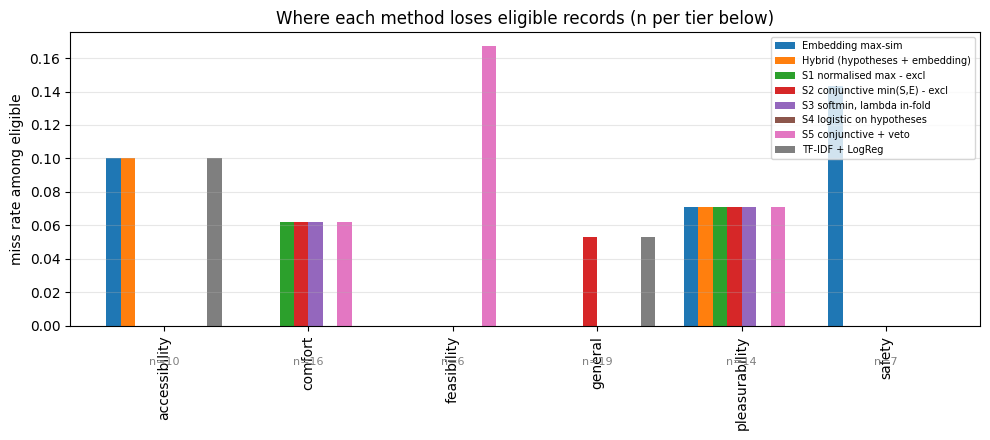

In [9]:
# ============================================================
# 8. Miss profile by tier, with counts and intervals
# ============================================================
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return (max(0, c - h), min(1, c + h))

env_cols = np.where(IS_ENV)[0]
env_tier = H.loc[env_cols, "tier"].values
pool["proxy_tier"] = env_tier[Z[:, env_cols].argmax(axis=1)]
pos_mask = y == 1

print("Eligible records per proxy tier (argmax over ENVIRONMENT hypotheses):")
tier_n = pool.loc[pos_mask, "proxy_tier"].value_counts()
print(tier_n.to_string())
thin = tier_n[tier_n < 10]
if len(thin):
    print(f"\n[!] {len(thin)} tiers have fewer than 10 eligible records "
          f"({', '.join(thin.index)}). A single missed abstract moves those rates by "
          f"{100/thin.min():.0f} points or more. Do not read them as evidence.")

COMPARE = [n for n in oof if not n.startswith("S0")]
rows = []
for name in COMPARE:
    s = oof[name]
    thr, _ = fit_operating_point(s, y)
    missed = pos_mask & (s < thr)
    for tier, grp in pool[pos_mask].groupby("proxy_tier"):
        idx = grp.index.values
        k, n = int(missed[idx].sum()), len(idx)
        lo, hi = wilson(k, n)
        rows.append({"approach": name, "tier": tier, "n": n, "missed": k,
                     "rate": round(k / n, 3), "ci": f"[{lo:.2f},{hi:.2f}]"})
miss = pd.DataFrame(rows)

print("\nMiss counts (rate) by tier - what matters is FLATNESS, not the mean:")
wide = miss.assign(cell=miss.missed.astype(str) + "/" + miss.n.astype(str)) \
           .pivot(index="tier", columns="approach", values="cell")
print(wide.to_string())

print("\nDispersion across tiers (record-weighted SD of the miss rate):")
disp = []
for name in COMPARE:
    sub = miss[miss.approach == name]
    mu = np.average(sub.rate, weights=sub.n)
    sd = np.sqrt(np.average((sub.rate - mu) ** 2, weights=sub.n))
    disp.append({"approach": name, "mean_rate": round(mu, 3), "SD_across_tiers": round(sd, 3),
                 "total_missed": int(sub.missed.sum())})
disp = pd.DataFrame(disp).sort_values("SD_across_tiers")
print(disp.to_string(index=False))
print("\nLower SD = misses spread evenly across dimensions. But check `total_missed`:")
print("with single-digit totals the SD is dominated by which one or two abstracts were lost,")
print("and the comparison cannot be reported as evidence either way.")

fig, ax = plt.subplots(figsize=(10, 4.5))
miss.pivot(index="tier", columns="approach", values="rate").plot(kind="bar", ax=ax, width=.8)
for i, t in enumerate(sorted(miss.tier.unique())):
    ax.annotate(f"n={tier_n[t]}", (i, 0), xytext=(0, -28), textcoords="offset points",
                ha="center", fontsize=8, color="grey")
ax.set_ylabel("miss rate among eligible"); ax.set_xlabel("")
ax.set_title("Where each method loses eligible records (n per tier below)")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 10. Prevalence sensitivity

The labelled pool is 37.5% eligible; the corpus will be far lower. WSS depends on prevalence,
so the number measured here is not the one you will experience. Positives are subsampled to
hit a range of assumed prevalences and the metric recomputed.

This is a re-weighting of the same 192 labels, not new evidence — it cannot see record types
absent from the pool. Only a random corpus sample can.

In [10]:
# ============================================================
# 9. Prevalence sensitivity
# ============================================================
def wss_at_prevalence(scores, yy, prev, n_boot=100, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(yy == 1)[0], np.where(yy == 0)[0]
    n_pos = int(round(prev * len(neg) / (1 - prev)))
    if n_pos < 10 or n_pos > len(pos):
        return np.nan
    vals = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(pos, n_pos, replace=False), neg])
        s, ys = scores[idx], yy[idx]
        thr = pick_threshold(s, ys)
        w, _ = wss(ys, (s >= thr).astype(int))
        vals.append(100 * w)
    return round(float(np.mean(vals)), 1)

prevs = [0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
rows = [{"approach": n, **{f"{int(p*100)}%": wss_at_prevalence(oof[n], y, p) for p in prevs}}
        for n in COMPARE]
print(f"WSS@95 by assumed corpus prevalence (pool is {y.mean()*100:.0f}% eligible):\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nThresholds here are fitted in-sample, so these are upper bounds; use them to compare")
print("methods against each other, not as an absolute forecast of workload.")

if CORPUS_PREVALENCE:
    N = 1696
    print(f"\nAt {CORPUS_PREVALENCE:.0%} prevalence over {N:,} records:")
    for n in COMPARE:
        w = wss_at_prevalence(oof[n], y, CORPUS_PREVALENCE)
        if not np.isnan(w):
            print(f"  {n:34s} ~{N*(1-(w/100+(1-TARGET_RECALL))):,.0f} abstracts to read")

WSS@95 by assumed corpus prevalence (pool is 38% eligible):

                       approach  35%  30%  25%  20%  15%  10%
       S1 normalised max - excl 11.2 12.6 16.0 15.8 21.4 21.9
 S2 conjunctive min(S,E) - excl 29.1 31.5 33.5 33.9 37.7 37.0
     S3 softmin, lambda in-fold 26.9 27.5 30.5 30.2 34.2 35.1
          S5 conjunctive + veto 22.3 25.4 28.8 30.8 34.4 35.5
      S4 logistic on hypotheses 30.1 33.0 36.3 35.9 42.6 43.0
              Embedding max-sim 36.7 39.9 43.8 46.0 52.1 54.2
                TF-IDF + LogReg 33.2 35.2 39.4 42.2 47.2 49.1
Hybrid (hypotheses + embedding) 38.3 41.6 45.8 48.7 55.0 54.3

Thresholds here are fitted in-sample, so these are upper bounds; use them to compare
methods against each other, not as an absolute forecast of workload.


## 11. Ablation against WSS, not AUC

v1 ranked sentences by their effect on AUC. AUC measures the whole ranking; the review only
lives at one cut point. A sentence can improve the global ordering and still hurt where the
threshold sits, or the reverse. This version re-runs leave-one-out through the same
out-of-fold protocol as the head-to-head, with fewer repeats to keep it affordable.

- `delta > 0` — removing it hurts; the sentence earns its place.
- `delta ≈ 0` — it contributes nothing; rewrite or drop it.
- `delta < 0` — removing it helps; it is doing damage, as `rule3_construct` was.

In [11]:
# ============================================================
# 10. Leave-one-hypothesis-out, measured at the operating point
# ============================================================
ABL_REPEATS = 3
def score_without(j):
    keep = ~IS_FLAG.copy(); keep[j] = False
    Zj = Z[:, keep]
    s_, e_, x_ = IS_SENS[keep], IS_ENV[keep], IS_EXCL[keep]
    if not (s_.any() and e_.any() and x_.any()):
        return None
    return np.minimum(Zj[:, s_].max(axis=1), Zj[:, e_].max(axis=1)) - Zj[:, x_].max(axis=1)

base, _ = evaluate("ablation-base", lambda tr, te: agg_S2(Z), n_repeats=ABL_REPEATS)
print(f"Baseline (S2, all sentences): WSS@95 {base['WSS@95']} | recall {base['recall']}\n")

abl = []
for j in np.where(~IS_FLAG)[0]:
    s = score_without(j)
    if s is None: continue
    r, _ = evaluate(f"-{H.tag[j]}", lambda tr, te, sc=s: sc, n_repeats=ABL_REPEATS)
    abl.append({"facet": H.facet[j], "tier": H.tier[j], "tag": H.tag[j],
                "WSS_without": r["WSS@95"], "delta": round(base["WSS@95"] - r["WSS@95"], 1),
                "recall_without": r["recall"], "text": H.text[j][:56]})
abl = pd.DataFrame(abl).sort_values("delta")
print(abl.to_string(index=False))
print("\nSentences at the top of this table are the ones to rewrite next.")

Baseline (S2, all sentences): WSS@95 18.9 | recall 0.963

 facet            tier            tag  WSS_without  delta  recall_without                                                     text
  excl  rule2_stimulus       stimulus         26.1   -7.2           0.968 Images are shown to human participants as stimuli in a s
  excl      simulation     simulation         24.9   -6.0           0.963 The results come from a computer simulation or an agent-
   env         comfort       acoustic         22.5   -3.6           0.963 The measured object is the level of noise on the street.
  excl rule3_construct      construct         19.6   -0.7           0.972 The stated objective of the study is to predict crime, h
   env   accessibility     continuity         19.4   -0.5           0.963 The measured object is whether the walking route is phys
   env     feasibility        surface         19.4   -0.5           0.963 The measured object is the sidewalk surface, its width, 
   env          safety   

## 12. Error analysis

In [12]:
# ============================================================
# 11. Error analysis at the operating point
# ============================================================
BEST = "S5 conjunctive + veto"          # set to whichever row won §8 among holds_95 = True
score = oof[BEST]
thr, margin = fit_operating_point(score, y)
s_max, e_max, x_max = facets(Z)
tag_of = lambda mask: H.loc[np.where(mask)[0], "tag"].values[Z[:, mask].argmax(axis=1)]
s_arg, e_arg, x_arg = tag_of(IS_SENS), tag_of(IS_ENV), tag_of(IS_EXCL)

fn = np.where((y == 1) & (score < thr))[0]
fp = np.where((y == 0) & (score >= thr))[0]
print(f"{BEST} | threshold {thr:.3f} (fitted at in-fold recall {margin}) "
      f"| FN {len(fn)} | FP {len(fp)}\n")

print("=" * 88)
print("MISSED ELIGIBLE - which facet failed?")
print("=" * 88)
why = ["EXCLUSION fired (" + x_arg[i] + ")" if x_max[i] > max(s_max[i], e_max[i])
       else ("SENSOR too low" if s_max[i] < e_max[i] else "ENVIRONMENT too low") for i in fn]
print(pd.Series(why).value_counts().to_string() if len(fn) else "none")
for i in fn[:6]:
    print(f"\n  [sensor {s_max[i]:+.2f} ({s_arg[i]}) | env {e_max[i]:+.2f} ({e_arg[i]}) "
          f"| excl {x_max[i]:+.2f} ({x_arg[i]})]")
    print("   ", pool.text[i][:180], "...")

print("\n" + "=" * 88)
print("FALSE POSITIVES - which exclusion should have fired?")
print("=" * 88)
print(pd.Series(x_arg[fp]).value_counts().to_string() if len(fp) else "none")
for i in fp[:6]:
    print(f"\n  [sensor {s_max[i]:+.2f} | env {e_max[i]:+.2f} ({e_arg[i]}) "
          f"| excl {x_max[i]:+.2f} ({x_arg[i]})]")
    print("   ", pool.text[i][:180], "...")

pool.assign(score=score, sensor=s_max, env=e_max, excl=x_max,
            excl_reason=x_arg, pred=(score >= thr).astype(int)) \
    .to_json(f"{OUT_DIR}/zeroshot_v2_pool.json", orient="records",
             indent=2, force_ascii=False)
print(f"\nSaved -> {OUT_DIR}/zeroshot_v2_pool.json")

S5 conjunctive + veto | threshold -1.170 (fitted at in-fold recall 0.95) | FN 3 | FP 74

MISSED ELIGIBLE - which facet failed?
EXCLUSION fired (simulation)    1
EXCLUSION fired (aerial)        1
EXCLUSION fired (stimulus)      1

  [sensor +0.70 (environmental) | env +0.04 (streetscape) | excl +1.30 (simulation)]
    Research on Spatial Perception in Virtual Historical Streets Based on Eye-Tracking and Physiological Sensing Data. Historical streets are an important component of urban form and e ...

  [sensor +1.14 (cv) | env +1.68 (surface) | excl +1.69 (aerial)]
    Sidewalk extraction using aerial and street view images. A reliable, punctual, and spatially accurate dataset of sidewalks is vital for identifying where improvements can be made u ...

  [sensor +0.72 (mobile) | env +0.77 (thermal) | excl +1.62 (stimulus)]
    Exploring the emotional effects of urban street design through virtual reality and electrodermal activity. This study investigates how urban street design paramete

## 13. The virtual-reality question — a gap in the criterion, not a bug

Two of v1's three missed eligible records were virtual-environment studies: eye-tracking in a
reconstructed historical street, and electrodermal response to street design in VR. Both were
blocked by `simulation` and `rule2_stimulus`.

The classifier was not wrong to hesitate. You labelled both **eligible**, but your own
adjudication rules point the other way — rule 2 excludes imagery used as survey stimulus,
and a virtual street is not field measurement. Yet these studies do instrument a person's
response to a controlled streetscape, which is a real form of pedestrian-environment sensing.

**The criterion does not currently decide this, and no amount of hypothesis rewriting can
decide it for you.** Three coherent positions:

1. **Exclude** — the measured object is a rendering, not a street; rule 1 (the source of the
   measurement defines scope) extends naturally to synthetic sources.
2. **Include** — the instrument measures a human response to a controlled streetscape; the
   virtual environment is apparatus, and rule 2 is about *showing pictures to raters*, not
   about instrumented exposure.
3. **Separate category** — report VR-based studies as their own stratum. Given how fast this
   literature is growing, a mapping review can reasonably treat it as a finding rather than a
   boundary case.

Whichever you choose, write it into the protocol as a fourth rule and re-label the affected
records consistently. The cell below lists them so the decision is made on the actual
evidence rather than in the abstract.

In [13]:
# ============================================================
# 12. Surface the virtual-environment records for adjudication
# ============================================================
vr_col = np.where(IS_FLAG & (H.tag == "virtual").values)[0][0]
vr_score = Z[:, vr_col]
KEY = r"virtual reality|virtual environment|\bVR\b|immersive|simulated street|game engine"
kw = pool["text"].str.contains(KEY, case=False, regex=True)
# top 5% on the NLI flag, or an explicit keyword - deliberately narrow, this is a
# queue a human has to read, not a filter
hi_flag = vr_score >= np.quantile(vr_score, 0.95)
cand = pool.index[hi_flag | kw.values]

print(f"{len(cand)} candidate virtual-environment records "
      f"({int(kw.sum())} by keyword, {int(hi_flag.sum())} in the top 5% of the NLI flag)\n")
if len(cand):
    view = pool.loc[cand, ["label", "origin"]].copy()
    view["vr_flag"] = vr_score[cand].round(2)
    view["kw"] = kw[cand].values
    view["current_pred"] = (score[cand] >= thr).astype(int)
    view["title"] = pool.loc[cand, "text"].str.slice(0, 90)
    print(view.to_string())
    print(f"\nLabelled eligible: {(pool.loc[cand, 'y'] == 1).sum()} | "
          f"not eligible: {(pool.loc[cand, 'y'] == 0).sum()}")
    kw_idx = pool.index[kw.values]
    if len(kw_idx) and pool.loc[kw_idx, "y"].nunique() > 1:
        print(f"\n[!] Among the {len(kw_idx)} records that explicitly mention a virtual "
              f"environment, {int((pool.loc[kw_idx,'y']==1).sum())} are labelled eligible and "
              f"{int((pool.loc[kw_idx,'y']==0).sum())} are not.")
        print("    That is an inconsistency in the adjudication, not in the model.")
        print("    Fix the rule, re-label these records, then re-run from section 6.")
    view.to_csv(f"{OUT_DIR}/vr_adjudication_queue.csv")
    print(f"\nSaved -> {OUT_DIR}/vr_adjudication_queue.csv")

12 candidate virtual-environment records (6 by keyword, 10 in the top 5% of the NLI flag)

                                label           origin  vr_flag     kw  current_pred                                                                                       title
15                        Not related             real     1.55  False             0  Balancing thermal comfort and pollutant mitigation in street canyons: a multi-objective op
21                        Not related             real     1.66  False             1  IEEE intell igent transportation Magazine representative. Reports on the special features 
22   Sensing of walkability dimension             real     1.69  False             0  Research on Spatial Perception in Virtual Historical Streets Based on Eye-Tracking and Phy
49   Sensing of walkability dimension             real     1.62   True             1  Toward Automated and Comprehensive Walkability Audits with Street View Images: Leveraging 
56   Sensing of walkabil

## 14. Full-corpus inference

In [17]:
# ============================================================
# 13. Apply to the corpus
# ============================================================
from pathlib import Path

# Localiza o arquivo ao executar o Jupyter pela raiz do projeto,
# pela pasta model/ ou pela pasta notebooks/.
corpus_candidates = [
    Path("data/02_document_search_results.json"),
    Path("../data/02_document_search_results.json"),
    Path.cwd() / "data" / "02_document_search_results.json",
    Path.cwd().parent / "data" / "02_document_search_results.json",
]

CORPUS_PATH = next(
    (path.resolve() for path in corpus_candidates if path.exists()),
    None,
)

if CORPUS_PATH is None:
    searched = "\n  - ".join(str(path.resolve()) for path in corpus_candidates)
    raise FileNotFoundError(
        "02_document_search_results.json não encontrado. "
        f"Caminhos verificados:\n  - {searched}"
    )

# O arquivo 02 possui os campos 'title' e 'abstract' separadamente.
corpus = pd.DataFrame(load_json(str(CORPUS_PATH)))

required_columns = {"title", "abstract"}
missing_columns = required_columns.difference(corpus.columns)

if missing_columns:
    raise KeyError(
        f"Campos obrigatórios ausentes no corpus: {sorted(missing_columns)}"
    )

# Trata valores nulos sem transformá-los na string "nan".
title = (
    corpus["title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

abstract = (
    corpus["abstract"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Monta o texto esperado pelo modelo: título + resumo.
abstract_suffix = abstract.where(abstract.eq(""), ". " + abstract)
corpus["text"] = (title + abstract_suffix).str.strip()

# Remove apenas registros que não possuem título nem resumo.
empty_text = corpus["text"].eq("")

if empty_text.any():
    print(
        f"[warning] Removendo {int(empty_text.sum())} registros "
        "sem título e sem resumo."
    )
    corpus = corpus.loc[~empty_text].copy()

corpus = corpus.reset_index(drop=True)

print(f"Corpus: {len(corpus)} registros")
print(f"Origem: {CORPUS_PATH}")
print(f"Sem abstract: {int(abstract.eq('').sum())}")

# Executa a inferência NLI.
Pc = score_matrix(
    corpus["text"].tolist(),
    H,
    "Corpus",
)

np.save(
    f"{OUT_DIR}/nli_matrix_corpus_v2.npy",
    Pc,
)

# Normalização interna do corpus.
Zc = normalise(Pc)

# Recupera os melhores parâmetros do método S5.
best_param = fit_param(
    S5_GRID,
    np.arange(len(y)),
)

lam, gate = [
    float(value.split("=")[1])
    for value in best_param.split(",")
]

print(f"Applying {BEST} with {best_param}")

sc = agg_S5(
    Zc,
    lam=lam,
    gate=gate,
)

# Calcula as facetas.
sm, em, xm = facets(Zc)

corpus["score"] = sc
corpus["sensor"] = sm
corpus["env"] = em
corpus["excl"] = xm

corpus["tier"] = env_tier[
    Zc[:, env_cols].argmax(axis=1)
]

exclusion_tags = H.loc[
    np.where(IS_EXCL)[0],
    "tag",
].values

corpus["excl_reason"] = exclusion_tags[
    Zc[:, IS_EXCL].argmax(axis=1)
]

corpus["vr_flag"] = Zc[:, vr_col].round(2)

# Ordena do registro mais relevante para o menos relevante.
corpus = (
    corpus
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

corpus["rank"] = np.arange(1, len(corpus) + 1)
corpus["kept"] = corpus["score"] >= thr

kept_count = int(corpus["kept"].sum())
keep_rate = float(corpus["kept"].mean())

print(
    f"\nThreshold {thr:.3f} retém "
    f"{keep_rate * 100:.1f}% do corpus "
    f"({kept_count:,} de {len(corpus):,} registros)."
)

if not (0.15 < keep_rate < 0.85):
    print(
        "[!] Retenção possivelmente implausível: as distribuições "
        "do pool e do corpus podem ser diferentes."
    )
    print(
        "    Considere também uma seleção por quantil, conforme "
        "o volume de artigos que pode ser revisado."
    )

# Salva os resultados mantendo os campos originais do arquivo 02.
json_output = f"{OUT_DIR}/corpus_ranked_v2.json"
csv_output = f"{OUT_DIR}/corpus_ranked_v2.csv"

corpus.to_json(
    json_output,
    orient="records",
    indent=2,
    force_ascii=False,
)

corpus.to_csv(
    csv_output,
    index=False,
)

print(f"\nSaved -> {json_output}")
print(f"Saved -> {csv_output}")

print("\nRetenção por dimensão:")
print(
    corpus
    .groupby("tier")["kept"]
    .agg(["mean", "sum", "count"])
    .rename(
        columns={
            "mean": "retention_rate",
            "sum": "kept",
            "count": "total",
        }
    )
    .round(3)
    .to_string()
)

Corpus: 1591 registros
Origem: C:\Users\vinic\Desktop\genai-smartcity\data\02_document_search_results.json
Sem abstract: 2
  [ 1/26] SCORED   540s  Data were collected by an instrument installed on a street...
  [ 2/26] SCORED  1122s  The study derives measurements from street-level photograp...


KeyboardInterrupt: 

## 15. Where this leaves the review

**Report the comparison, not a winner.** Four screening strategies under one protocol, with
intervals, and a stated rule that only `holds_95 = True` rows are eligible for the claim.
Reviews that report a single WSS with no comparator and no interval are the norm and are not
better for it.

**Do not automate exclusion below ~30% WSS@95.** Screen in ranked order instead, record where
you stopped, and publish the prioritisation curve. That asks nothing of the classifier it
cannot deliver, and it is fully defensible.

**The binding constraint is still labels.** Everything here is calibrated on 192 abstracts
drawn from an enriched pool. A random sample of ~150 corpus records, screened blind, is the
one thing that would give an unbiased prevalence, an unbiased WSS, and enough per-tier counts
for §9 to mean something. No modelling choice substitutes for it.

**Then, in order:** resolve the VR question in §13; rewrite whatever §11 flags; and if the
budget allows, label in uncertainty order around the threshold rather than at random
(Wallace et al. 2010), which reaches target recall with far fewer labels and composes with
any scorer above.